# 🧠🤖 O Neurônio de McCulloch-Pitts como Classificador

## Preparação

Copie a classe `MCPNeuron` construída na aula anterior para a célula abaixo. 

In [102]:
# resposta:

class MCPNeuron:
    """McCulloch-Pitts Neuron model

    Simulates a biologic neuron using a set of weights and
    an activation threshold.
    """

    def __init__(self, weights: list[float], bias: float):
        self.weights = weights
        self.bias = bias

    def forward(self, x: list[float]): #verificar se os entradas * pesos >= bias
        total = 0
        if(len(x) == len(self.weights)):
            for i in range (len(x)):
                total += x[i] * self.weights[i]
            if(total - self.bias >= 0):
                return 1
        return 0
       

## O Neurônio MCP como um Classificador Binário

Apesar de simples, o neurônio MCP pode ser visto como um classificador binário. 

Para mostrar como isso pode ser feito, vamos utilizar um conjunto de dados de exemplo apresentado abaixo. 

O conjunto de dados é composto por um conjunto pontos com coordenadas $(x_1, x_2)$, cada um podendo ser ou da classe $0$ ou da classe $1$.

In [103]:

import numpy as np
import pandas as pd

df = pd.DataFrame([[3.5, 4.25, 1],
     [4, 3, 1],
     [4, 4, 1],
     [4.5, 1.75, 1],
     [4.9, 4.5, 1],
     [5, 4, 1],
     [5.5, 2.5, 1],
     [5.5, 3.5, 1],
     [0.5, 1.5, 0],
     [1, 2.5, 0],
     [1.25, 0.5, 0],
     [1.5, 1.5, 0],
     [2, 2, 0],
     [2.5, 0.75, 0]], columns = 'x1 x2 Classe'.split())

df

,x1,x2,Classe
0,3.50,4.25,1
1,4.00,3.00,1
2,4.00,4.00,1
3,4.50,1.75,1
4,4.90,4.50,1
5,5.00,4.00,1
6,5.50,2.50,1
7,5.50,3.50,1
8,0.50,1.50,0
9,1.00,2.50,0


Os elementos do conjunto de dados e as respectivas classes podem ser visualizados na Figura abaixo.

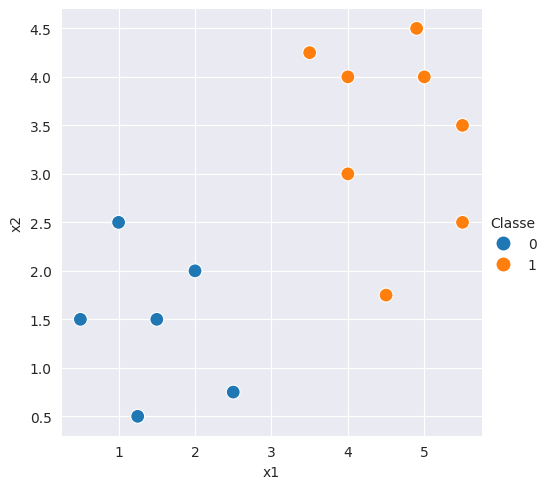

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
sns.relplot(data = df, x = 'x1', y = 'x2', hue = 'Classe', s = 100); # o ponto e vírgulo previne a geração de outputs

Considere que as coordenadas dos pontos serão utilizadas como entrada para o neurônio MCP. 

Vamos definir os parâmetros do neurônio como $\mathbf{w} = [ 2.9, 1.0 ]$  e  $b = 10$.

Abaixo, criamos um neurônio para atuar como classificador e o utilizamos para predizer as classes de todos os elementos do conjunto de dados. As classes preditas foram adicionadas ao ``DataFrame`` original dos dados. Como pode ser observado, o neurônio foi capaz de classificar corretamente todos elementos do conjunto de dados.

In [105]:
classifier = MCPNeuron(weights=[2.9, 1.0], bias=10)

y_pred = [classifier.forward(x) for x in df[['x1', 'x2']].values]
df['Classe Predita'] = y_pred
df

,x1,x2,Classe,Classe Predita
0,3.50,4.25,1,1
1,4.00,3.00,1,1
2,4.00,4.00,1,1
3,4.50,1.75,1,1
4,4.90,4.50,1,1
5,5.00,4.00,1,1
6,5.50,2.50,1,1
7,5.50,3.50,1,1
8,0.50,1.50,0,0
9,1.00,2.50,0,0


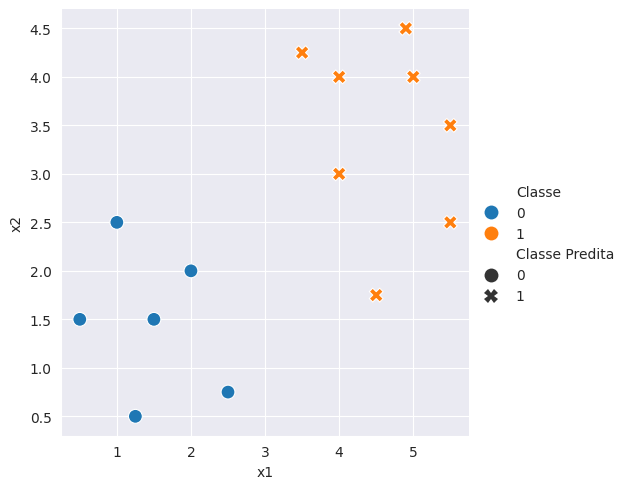

In [106]:
#@title
sns.relplot(data = df, x = 'x1', y = 'x2', hue = 'Classe', style = 'Classe Predita', s = 100);

## Atividade: Avaliando a Performance do Classificador usando a Acurácia

Implemente uma função para calcular a acurácia. Esta métrica é dada pelo percentual de amostras classificadas corretamente. Ela é obtida dividindo o número de itens em que a classe predita é igual à esperada pelo número total de amostras. 

Adicione asserts para verificar se os tamanhos das listas de entrada são iguais e se estes tamanhos são maiores que zero.

In [ ]:
# resposta:

def accuracy_metric(expected, predicted):
    if (len(expected) == len (predicted) and len(expected) > 0):
        f = 0
        for i in range (len(expected)):
            if(expected[i] == predicted[i]):
                f += 1
        return f/len(expected)
    return 0


In [108]:
expected = df['Classe'].values
predicted = df['Classe Predita'].values

accuracy_metric(expected, predicted)

1.0

## O Neurônio MCP é capaz de Resolver apenas Problemas Linearmente Separáveis

A Figura a seguir apresenta as regiões de decisão do classificador. Qualquer elemento/ponto que esteja na área azul claro será classificado como pertencente à classe $0$. Analogamente, pontos na região vermelho claro serão classificados como sendo da classe $1$.

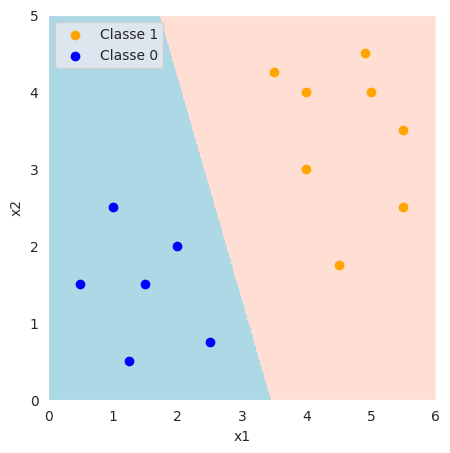

In [109]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def draw_classification_region(data: pd.DataFrame, classifier: MCPNeuron):
    cmap_light = ListedColormap(['#ADD8E6', '#AAFFAA', '#ffdfd4'])

    h = .01

    x_min = data['x1'].min() - 0.5
    x_max = data['x1'].max() + 0.5
    y_min = data['x2'].min() - 0.5
    y_max = data['x2'].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))

    f, axs = plt.subplots(1, 1, figsize=(5, 5))

    Z = np.array([classifier.forward([x1, x2]) for x1, x2 in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)
    axs.pcolormesh(xx, yy, Z, cmap = cmap_light, shading = 'auto')

    axs.scatter(df[df['Classe'] == 1]['x1'], df[df['Classe'] == 1]['x2'], color = 'orange', label = 'Classe 1')
    axs.scatter(df[df['Classe'] == 0]['x1'], df[df['Classe'] == 0]['x2'], color = 'blue', label = 'Classe 0')

    plt.xlabel('x1')
    plt.ylabel('x2')

    plt.xlim((x_min, x_max))
    plt.ylim((y_min, y_max))
    plt.legend(loc = 'best');


draw_classification_region(df, classifier)


Como pode ser visto, o neurônio MCP é um classificador linear, ou seja, as regiões de decisão são delimitadas por uma função linear.

Isto faz sentido quando observamos que $\mathbf{w}^T \mathbf{x} + b$ lembra a fórmula utilizada para representar hiperplanos (retas em 2D, planos em 3D, etc.). Em particular, o hiperplano definido por $\mathbf{w}^T \mathbf{x} + b = 0$ é a fronteira de decisão do classificador (a reta de separação na figura acima). Analisando a operação do neurônio como uma operação linear, percebemos que o vetor $\mathbf{w}$ define a inclinação do hiperplano e $b$ define o deslocamento do hiperplano em relação à origem.

Concluímos, assim, que **o neurônio MCP é capaz de resolver bem apenas problemas linearmente separáveis**, isto é, aqueles em que a maioria dos dados de classes diferentes podem ser separados por um hiperplano. Infelizmente, a maioria dos problemas interessantes não são linearmente separáveis e redes neurais mais complexas são necessárias para atacar estes problemas. 





### Visualização do Hiperplano de Decisão

A célula abaixo demonstra como visualizar o plano definido pelos parâmetros do neurônio MCP. 

Para ganhar intuição geométrica dos efeitos de modificar os parâmetros do neurônio, brinque com os valores na última linha e execute a célula novamente para verificar o efeito no plano.


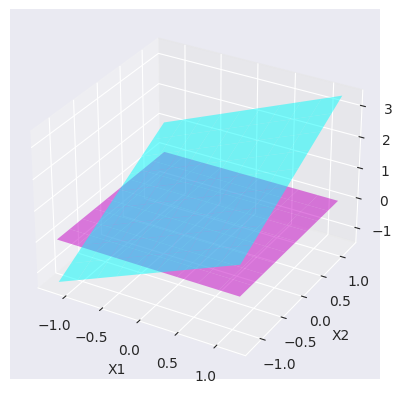

In [110]:
import numpy as np
import matplotlib.pyplot as plt


def plot_plane(w1, w2, bias, x1_range=(-1.2, 1.2), x2_range=(-1.2, 1.2)):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Create grid
    x1 = np.linspace(*x1_range, 10)
    x2 = np.linspace(*x2_range, 10)
    X1, X2 = np.meshgrid(x1, x2)
    Z = w1 * X1 + w2 * X2 + bias
    Z2 = 0 * X1 + 0 * X2 + 0

    # Plot the surface
    ax.plot_surface(X1, X2, Z, alpha=0.5, rstride=1,
                    cstride=1, color='cyan', edgecolor='none')
    ax.plot_surface(X1, X2, Z2, alpha=0.5, rstride=1,
                    cstride=1, color='magenta', edgecolor='none')

    # Set labels
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Z')

    plt.show()

# Modifique os valores abaixo e verifique como o plano é afetado
plot_plane(w1=1, w2=1, bias=1)

## Atividade: "Treinando" o Classificador Manualmente

Crie um objeto do tipo MCPNeuron no local indicado e inicialize pesos e bias de forma a maximizar a performance do classificador. 

O treinamento do modelo é o ajuste dos parâmetros (pesos e bias). Neste exemplo, estamos fazendo isto manualmente e nas próximas aulas aprenderemos como fazer isto automaticamente.

A célula abaixo cria uma base de dados, classifica as amostras, desenha a região de classificação e mostra a acurácia na tela.

>> Accuracy:  0.85


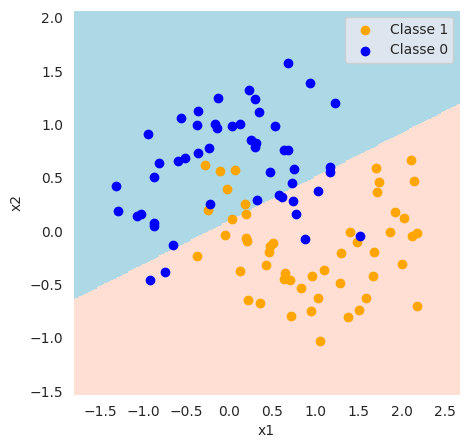

In [101]:
# resposta:

# imports
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

# cria o dataset
x, y = make_moons(noise=0.3, random_state=0)
data = np.concat([x, np.expand_dims(y, axis=1)], axis=1)
df = pd.DataFrame(data, columns = 'x1 x2 Classe'.split())

# define o classificador

##########################
# ADICIONE A RESPOSTA ABAIXO
##########################
classifier = MCPNeuron(weights=[2.09, -5.1], bias=-0.5)

# desenha as regicoes de classificacao
draw_classification_region(df, classifier)

# calcula a metrica
predicted = [classifier.forward(sample) for sample in x]
print(">> Accuracy: ", accuracy_metric(expected=y, predicted=predicted))

## Referências

- Machine Learning, Tom Mitchell, McGraw Hill, 1997.

- McCulloch and Pitts: A logical calculus of the ideas immanent in nervous activity. Bulletin of Mathematical Biophysics, 1943.

- Rosenblatt: The perceptron - a probabilistic model for information storage and organization in the brain. Psychological Review, 1958.

- Minsky and Papert: Perceptrons: An introduction to computational geometry. MIT Press, 1969.

- Mohammed J. Zaki, Wagner Meira, Jr., Data Mining and Machine Learning: Fundamental Concepts and Algorithms, 2nd Edition, Cambridge University Press, March 2020.